* population *

=== Population Statistics ===
population_normal_mean: 49.9786
population_normal_var: 100.6836
population_lognorm_mean: 39.9877
population_lognorm_var: 705.0190

=== Sample Statistics ===
sample_normal_mean: 51.6586
sample_normal_var: 90.2524
sample_lognorm_mean: 40.1506
sample_lognorm_var: 688.1184

Mean, Median, Mode for sample_normal:
Mean: 51.6586
Median: 52.0650
Mode(s): [25.116726465870105, 26.15693211214254, 29.28622820661843, 31.581022270421425, 32.240177530381075, 32.89396645563485, 33.24419550375906, 34.16097176514277, 35.760418878023934, 35.77770350493793, 36.00921571815525, 37.409350885518066, 37.450773319977074, 38.46293676369636, 38.502925271025944, 38.69821270515317, 38.75878141139226, 38.79952577530128, 39.02631681028933, 39.0783636728191, 39.22279254208398, 39.23320872528986, 39.70027725223064, 39.7597140911362, 40.11408892849083, 40.17675727723224, 40.28343265458714, 41.07212484508116, 41.19988018309236, 41.317390384016676, 41.40386486121546, 41.61638119999192, 42.0179

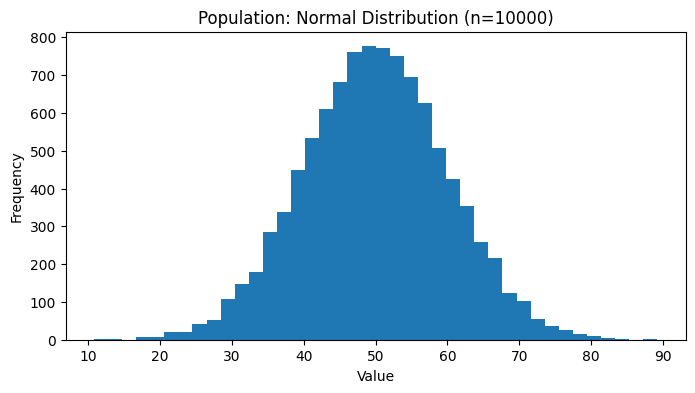

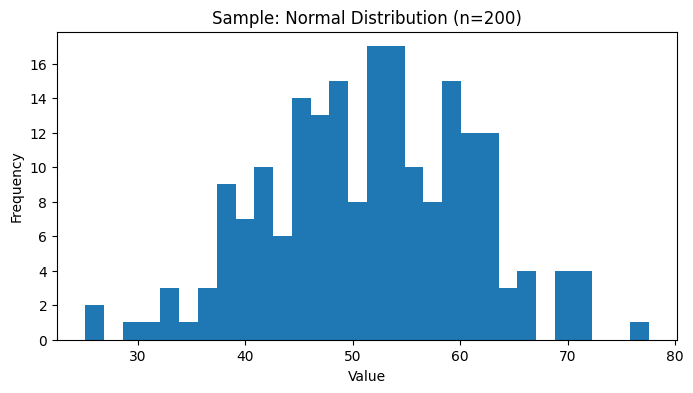

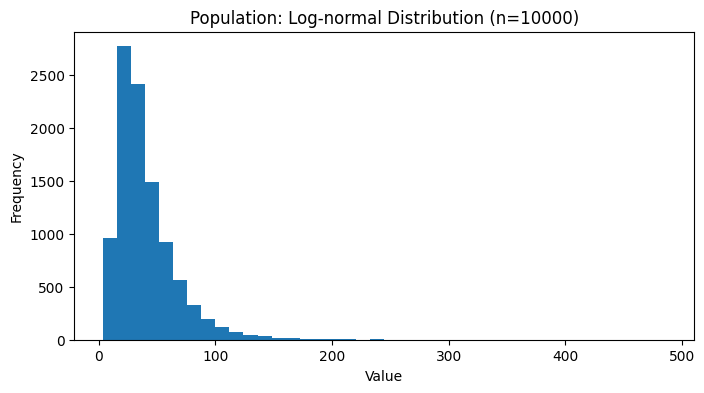

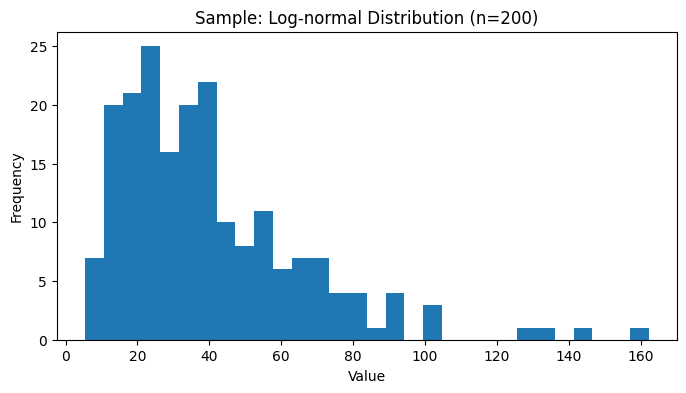

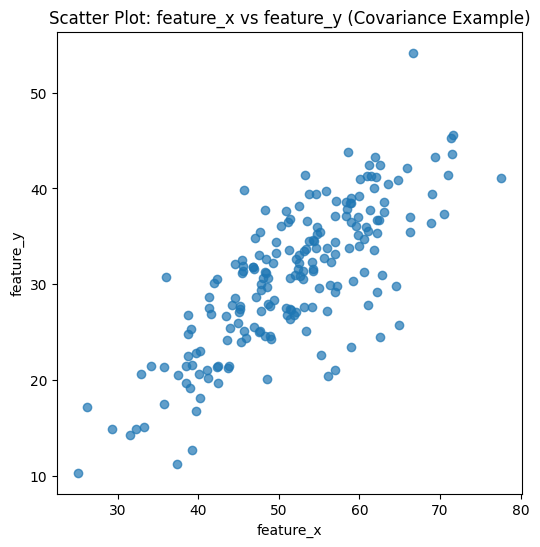

In [1]:
# -------------------------------------------------------------
# Example: Basic Statistics Concepts in Machine Learning
# -------------------------------------------------------------
# Covers:
# 1. Population vs Sample
# 2. Normal (Gaussian) Distribution
# 3. Log-normal Distribution
# 4. Mean, Median, Mode
# 5. Covariance and Correlation
# 6. Visualizations using Matplotlib
# -------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statistics import mode

# For reproducibility
np.random.seed(42)

# -------------------------------------------------------------
# 1. Create Population Data
# -------------------------------------------------------------
population_size = 10000

# Normal Distribution (mean=50, std=10)
population_normal = np.random.normal(loc=50, scale=10, size=population_size)

# Log-normal Distribution (log-mean=3.5, sigma=0.6)
population_lognorm = np.random.lognormal(mean=3.5, sigma=0.6, size=population_size)

# -------------------------------------------------------------
# 2. Draw a Random Sample from Population
# -------------------------------------------------------------
sample_size = 200
sample_normal = np.random.choice(population_normal, size=sample_size, replace=False)
sample_lognorm = np.random.choice(population_lognorm, size=sample_size, replace=False)

# Create DataFrame
df_sample = pd.DataFrame({
    "sample_normal": sample_normal,
    "sample_lognorm": sample_lognorm
})

# Add correlated features to demonstrate covariance
noise = np.random.normal(scale=5, size=sample_size)
df_sample["feature_x"] = df_sample["sample_normal"]
df_sample["feature_y"] = 0.6 * df_sample["feature_x"] + noise  # correlated with feature_x

# -------------------------------------------------------------
# 3. Compute Population and Sample Statistics
# -------------------------------------------------------------
pop_stats = {
    "population_normal_mean": np.mean(population_normal),
    "population_normal_var": np.var(population_normal),  # population variance
    "population_lognorm_mean": np.mean(population_lognorm),
    "population_lognorm_var": np.var(population_lognorm)
}

sample_stats = {
    "sample_normal_mean": np.mean(sample_normal),
    "sample_normal_var": np.var(sample_normal, ddof=1),  # sample variance
    "sample_lognorm_mean": np.mean(sample_lognorm),
    "sample_lognorm_var": np.var(sample_lognorm, ddof=1)
}

# Mean, Median, Mode
mean_normal = df_sample["sample_normal"].mean()
median_normal = df_sample["sample_normal"].median()
mode_normal = df_sample["sample_normal"].mode().tolist()

# Covariance and Correlation
cov_matrix_np = np.cov(df_sample["feature_x"], df_sample["feature_y"])
cov_pandas = df_sample[["feature_x", "feature_y"]].cov()
pearson_corr = df_sample["feature_x"].corr(df_sample["feature_y"])

# -------------------------------------------------------------
# 4. Display Statistics
# -------------------------------------------------------------
print("=== Population Statistics ===")
for k, v in pop_stats.items():
    print(f"{k}: {v:.4f}")

print("\n=== Sample Statistics ===")
for k, v in sample_stats.items():
    print(f"{k}: {v:.4f}")

print("\nMean, Median, Mode for sample_normal:")
print(f"Mean: {mean_normal:.4f}")
print(f"Median: {median_normal:.4f}")
print(f"Mode(s): {mode_normal}")

print("\nCovariance Matrix (NumPy):")
print(cov_matrix_np)

print("\nCovariance (Pandas):")
print(cov_pandas)

print(f"\nPearson Correlation: {pearson_corr:.4f}")

# -------------------------------------------------------------
# 5. Visualizations
# -------------------------------------------------------------

# 1) Population Normal Distribution
plt.figure(figsize=(8,4))
plt.hist(population_normal, bins=40)
plt.title("Population: Normal Distribution (n=10000)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

# 2) Sample Normal Distribution
plt.figure(figsize=(8,4))
plt.hist(sample_normal, bins=30)
plt.title("Sample: Normal Distribution (n=200)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

# 3) Population Log-normal Distribution
plt.figure(figsize=(8,4))
plt.hist(population_lognorm, bins=40)
plt.title("Population: Log-normal Distribution (n=10000)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

# 4) Sample Log-normal Distribution
plt.figure(figsize=(8,4))
plt.hist(sample_lognorm, bins=30)
plt.title("Sample: Log-normal Distribution (n=200)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

# 5) Scatter Plot (Covariance Visualization)
plt.figure(figsize=(6,6))
plt.scatter(df_sample["feature_x"], df_sample["feature_y"], alpha=0.7)
plt.title("Scatter Plot: feature_x vs feature_y (Covariance Example)")
plt.xlabel("feature_x")
plt.ylabel("feature_y")
plt.show()

# -------------------------------------------------------------
# 6. Optional: Export Data to CSV
# -------------------------------------------------------------
# df_sample.to_csv("sample_statistics_data.csv", index=False)
# print("\nSample data saved as 'sample_statistics_data.csv'")
